# Knee MRI — preprocessing & model pipeline for IMAGES

## 0. Reality check — five things we had wrong

Correcting these now is cheaper than correcting them.

| # | What we assumed | What is actually true |
|---|---|---|
| 1 | "Each **series** gives 3 arrays: X / Y / Z, ~40 images each" | A series is **one** acquisition in **one** plane — that is why `train_series.csv` has an `Anatomical_Plane` column. A study averages **~5.5 series**. Our unit of work is the **study**, reduced to **4 fixed slots** (§2). Reslicing one plane into the others fabricates resolution: through-plane is 3–4 mm vs 0.3–0.6 mm in-plane, and the study already contains a real acquisition in each plane. |
| 2 | "One specialised **model** per label" | Right instinct, wrong unit. 12 fine-tuned backbones × ~1,300 test studies will not fit the **9-hour** GPU limit. One shared encoder + **12 specialised heads** gives each label its own attention, threshold and colour map at 1/12 of the cost. See §5. |
| 3 | "Train on images only, ignore reports, don't trust the 58" | With the 58 excluded and reports excluded there are **zero** labels. Resolution: the reports become a **label file**, not a module — see §0.1. |
| 4 | "The model returns a knee with a colour spot on the injury" | There are **no masks and no boxes** in this dataset, only study-level 0/1. The colour must come from **weakly-supervised** localisation (CAM / MIL attention). Cheaper to build, but coarse and not always right — §7 gates it. |
| 5 | "Download the data" | It is **569 GB**, and our competition-download endpoint is 429-locked. We use a **17.4 GB public preprocessed mirror** instead, and Kaggle GPU for the heavy pass. §2. |

### Where supervision actually comes from

- **58 of 4,407** studies have all 12 labels. The other **4,349** have a `Report` and nothing else.
- The 58 are **radiologist-adjudicated** — two MSK radiologists plus an adjudicator, the same
  process that produced the hidden test ground truth. They are the *most* reliable labels we have.
- But every one of the 58 has ≥1 positive finding, so the set is **selection-biased**, and 58
  across folds is ~12 per fold where the standard error of an AUC is ≈0.15.
  → **Never train on them. Always audit against them.**
- `test.csv` has **no Report column**. Any text branch is a *training-time teacher only*.
  Treating report text as a test feature is the classic fatal error in this competition.
  Module `M3` enforces this with an assertion (§4).

---
## 1. Architecture at a glance

```
  ┌─────────────── KAGGLE ONLY — 569 GB already mounted at /kaggle/input ───────────────┐
  │                                                                                     │
  │  train_series.csv ─► M1 assign_slots ─► slots.csv ─► M2 dicom→volume ─► volumes.npy │
  │   24,371 rows          pandas, 30 s      4407 × 4      CPU kernel        uint8       │
  │   plane + fluid        NO dicom reads                  resumable      (4,24,224,224) │
  │                                                                            │        │
  │                                                    M4 encode  ◄────────────┘        │
  │                                                 GPU, DINOv2-S frozen                │
  └────────────────────────────────────────────────────────┬────────────────────────────┘
                                                           ▼
   train.csv ─► M3 label factory ─► soft_targets.csv   features.npy  [N,4,K,D]  ~600 MB
    (Report)    merge public LLM     Y (soft) + W       published as a Kaggle dataset,
                label CSVs           (W=0 ⇒ masked)     then pulled to the laptops
                                          │                    │
                                          └─────────┬──────────┘
                                                    ▼
                              M5 heads   —   LAPTOP, ~20 s per experiment
                              StandardScaler → PCA(512) → 12 × weighted Ridge
                                                    │
                           ┌────────────────────────┴────────────────────────┐
                           ▼                                                 ▼
              submit kernel (GPU, internet OFF)                  M5 cam ─► M6 render packs
              decodes the HIDDEN test from DICOM                 exact linear decomposition
                           │                                                 │
                           ▼                                                 ▼
                    submission.csv                              app/  2D tri-planar + 3D
                   (Kaggle: 12 AUCs)                            + 12 confidence bars
```

---
## 2. Data

| Artifact | Path | Shape / dtype | Size |
|---|---|---|---|
| competition CSVs | `data/*.csv` | verbatim | ~25 MB |
| LLM report labels | `data/labels_llm_*.csv` | 4,407 × 13 | <1 MB |
| series manifest | `data/manifest/manifest_series.parquet` | 24,371 rows | ~8 MB |
| **canonical volume** | `data/processed/<profile>/<study>/<series>.npy` | `uint8 (24,224,224)` | 1.2 MB |
| slot assignment | `data/manifest/slots.csv` | 4,407 × 5 | 600 KB |
| study tensor | *(in memory, built from 4 slots)* | `uint8 (4,24,224,224)` | — |
| **soft targets** | `data/derived/soft_targets.csv` | 4,407 × 40 | ~2 MB |
| label audit | `data/derived/label_audit.csv` | 12 × 8 | 2 KB |
| folds | `data/derived/study_folds.csv` | 4,407 × 4 | 400 KB |
| **cached features** | `data/features/features_<tag>.npy` | `float16 [N,4,K,D]` | ~600 MB |
| feature mask | `data/features/mask_<tag>.npy` | `bool [N,4,K]` | 265 KB |
| heat maps | `data/_heat/<study>.npz` | `uint8 (12,S,gh,gw)` | ~14 KB |
| **render pack** | `data/render_packs/<study>.npz` | `gray_iso uint8 128³`<br>`heat_iso uint8 (12,64³)` | ~5 MB |
| submission | `/kaggle/working/submission.csv` | 1,300 × 13 | ~150 KB |

**Frozen constants**

```python
TARGETS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
           "Medial OA", "Lateral OA", "PF OA", "Effusion",
           "Synovitis", "Baker's", "Contusion", "Fracture"]   # submission order. NEVER sort.

# A study averages ~5.5 series. We take 4 fixed SLOTS,
# because fluid-sensitive vs structural matters as much as the plane:
#   Contusion / Fracture / Effusion are invisible outside a fluid-sensitive sequence.

SLOTS = [("SAG_FLUID",  "Sagittal", 1),   # 94.2% of studies have one
         ("SAG_STRUCT", "Sagittal", 0),   # 96.8%
         ("COR_FLUID",  "Coronal",  1),   # 96.4%
         ("AX_FLUID",   "Axial",    1)]   # ~100%
         
# AX_STRUCT is DROPPED because it is present for only 19.4% of studies, so the head would spend most of its capacity learning "this slot is missing".
# Fat_Suppression is DROPPED — byte-identical to Fluid_Sensitive across all 24,371 rows, despite the official docs claiming otherwise. Re-assert on the test manifest, warn not fail.

DEPTH, SIZE, CROP_MM = 24, 224, 130.0   # 0.580 mm/px. 224 = 16x14 -> DINOv2 ViT-S/14 compatible
WINDOW_PCT = (0.5, 99.5)                # per SERIES, on the cropped foreground
CACHE_TAG  = "v1_d24_s224_c130_4slot"   # in every filename; a mismatched tag REFUSES to load
```

**Serialisation rule:** `.npy` / `.npz` / `.csv` only.

---
## 3. Module pseudocode


### — Data access & materialisation

In [22]:
# src/data/kaggle_pull.py

def preflight():
    # print versions, CACHE_TAG, where() -> kaggle | colab | local
    ...

def census(train_df, series_df):
    # slot fill rate per (plane, fluid); drop any slot below 0.90
    # is Fluid_Sensitive == Fat_Suppression? count fully-labelled studies (print, don't assert)
    # count duplicate Reports -> they leak across folds
    ...

TIERS = {
    "T0_meta":  "competition + LLM label CSVs   ~25 MB   laptop",
    "T1_dicom": "8 studies of raw DICOM         ~1 GB    laptop",
    "T2_gold":  "the 58 adjudicated studies     ~1.4 GB  laptop",
    "T3_full":  "preprocessed .npz mirror       17 GB    Kaggle/Colab",
}

def authenticate():
    # .env: KAGGLE_USERNAME + KAGGLE_API_TOKEN, as in kaggleFetch.ipynb
    ...

def pull_tier(tier, dest="data/"):
    # skip files already on disk; backoff on 429; never parallelise
    # datasets endpoint works, competition endpoint is 429-locked
    ...

def build_manifest(split="train"):
    # one row per series — nothing downstream walks the filesystem
    # -> manifest_series.parquet
    ...

def verify_tier(tier):
    # sha256 every file against DATASETS.lock.json so all four of us have identical bytes
    ...

### M2 — DICOM → canonical volume  *(the core preprocessing)*
**goal** every study becomes one comparable `uint8 (3,24,224,224)` tensor
**in** a series directory · **out** `data/processed/<profile>/<study>/<series>.npy`

Five traps live in this module. Each line below exists because of one.

In [23]:
# src/preprocess/dicom_to_volume.py

def read_series(series_dir):
    # order slices by ImagePositionPatient on the normal, never by filename
    # pylibjpeg required: JPEG-Lossless and JPEG-2000 both occur
    # -> RawSeries(vol int16 (S,H,W), spacing, dirs, meta)
    ...

def normalize_intensity(vol):
    # one 1-99.5 percentile window per SERIES, pooled over slices
    # -> uint8
    ...

def crop_to_physical_extent(vol, spacing, mm=130):
    # PixelSpacing varies 3.4x -> crop to constant mm, then resize
    ...

def resolve_study_laterality(study_id, series_df):
    # decide the side once per STUDY, else planes disagree on which side is medial
    # -> (side in {L,R,None}, source, confident)
    ...

def fix_laterality(vol, plane, side, confident):
    # coronal/axial -> flip last axis; sagittal -> reverse stack order
    # not confident -> do nothing, a wrong flip is worse than none
    ...

def preprocess_series(series_dir, profile, side, confident, csv_plane=None):
    # read -> normalize -> crop -> resize -> fix_laterality, cv2.INTER_AREA
    # meta carries mm_per_px and slice_spacing_mm; they vary 3.4x, never constants
    # -> (uint8 (24,224,224) | None, meta)
    ...

def assign_slots(series_df):
    # pick 4 series per study from train_series.csv alone, no DICOM
    # -> slots.csv: study_uid, SAG_FLUID, SAG_STRUCT, COR_FLUID, AX_FLUID
    ...

def build_study_tensor(study_id, slots_row, profile):
    # missing slot -> zeros + present_mask 0, never impute
    # -> (uint8 (4,24,224,224), present_mask (4,), meta)
    ...

PROFILES = {
    "default": dict(mm=130, size=224, slices=24),   # full corpus
    "hires":   dict(mm=130, size=384, slices=32),   # gold-58, local dev
    "context": dict(mm=200, size=224, slices=24),   # STRETCH: full FOV for Baker's
}

### M3 — Supervision: reports → soft targets
**goal** turn 4,349 report-only studies into trainable soft labels **with a trust weight**
**in** `train.csv`, public LLM label CSVs · **out** `soft_targets.csv`, `label_audit.csv`

This is the highest-leverage module in the project and the one most likely to be built wrong.

In [24]:
# src/labels/report_labels.py

def load_public_llm_labels():
    # published LLM labels cover all 4,407 studies; no NLP pipeline of our own
    # use the single best source, not a blend
    # keep pilkwang for __conf/__verdict as this is the only published trust signal
    ...

def audit_against_gold(soft, gold_58):
    # per label: agreement, false_pos (negation missed), false_neg (never dictated)
    # -> label_audit.csv
    ...

def trust_weights(audit):
    # silence: Medial Meniscus 5.7 .. Fracture 56.4, Synovitis 84.2
    # a silent cell gets W = 0, not a prior — it is a MISSING label, so masked BCE
    # -> W float32 (N,12), Y float32 (N,12)
    ...

def make_folds(train, n=5):
    # StratifiedGroupKFold on StudyInstanceUID, de-duped on report_md5 first
    # the gold 58 are never in a training fold
    # -> study_folds.csv
    ...

def assert_label_factory_only(module):
    # test.csv has no Report column
    # assert nothing here is importable by src/models/infer.py
    ...

### M4 — Encode once: frozen backbone → cached features
**goal** the one expensive pass, run ~3× for the whole project
**in** study tensors · **out** `features_<tag>.npy float16 [N,4,K,D]`

In [25]:
# src/models/encode.py

BACKBONES = {   # pre-attached Kaggle Models — scoring kernels have no internet
    "dinov2_s":    "metaresearch/dinov2/PyTorch/small/1   384-d, strongest frozen",
    "effnet_b3":   "timm/tf-efficientnet/PyTorch/b3/1     cheap 2.5D baseline",
    "radimagenet": "marwanmath/resnet-50-radimagenet      medical pretrain",
}

def to_model_input(vol_uint8):
    # 3 channels from ADJACENT slices (2.5D), not one slice repeated
    ...

def encode_all(studies, backbone="dinov2_s", tag="v1"):
    # per study/slot/slice: forward, keep [cls | mean_patch | max_patch], float16
    # encode the test set first and never subsample it
    # -> features_<tag>.npy [N,4,K,D], mask_<tag>.npy [N,4,K]
    ...

def cache_is_stale(tag):
    # hash (profile, backbone, K, size) into the tag
    # a stale cache looks like a bad idea, not a bad file
    ...

### M5 — The 12 specialist heads
**goal** each label gets its own model, sharing one encoder
**in** cached features + soft targets · **out** OOF predictions, `submission.csv`

This is §5 in code form — read that section first for *why* each head differs.

In [26]:
# src/models/heads.py

def pool_features(feats, mask):
    # masked mean+max over the K slices of each slot
    # -> [N, 4*2*D]
    ...

def fit_heads(X, Y, W, folds):
    # ridge first: StandardScaler -> PCA(512) -> 12x weighted RidgeCV, ~20 s on a laptop
    # -> head_scaler.npz, head_pca.npy, head_ridge.npz   (never a pickle)
    ...

class SpecialistHead:   # -> nn.Module once torch lands (STRETCH, after Ridge plateaus)
    # attention over slices, then over slots, then linear -> 1 logit
    # that attention is the localisation signal M6 consumes
    ...

def train_head(label, feats, mask, y, w, folds):
    # loss = (BCE(pred, y_soft) * W[:, label]).sum() / W[:, label].sum()
    # per-label knobs: plane prior, slice window, profile, pos_weight
    ...

def validate(oof, gold_58):
    # OOF measures agreement with the REPORTS -> regression guard, not a score estimate
    # the leaderboard is the only real validation; 5 submissions/day
    ...

def fuse_and_submit(oof, test_preds):
    # rank order only: no calibration, ensemble by rank mean
    # -> submission.csv, cols exactly ['StudyInstanceUID'] + TARGETS
    ...

### M6a — Weakly-supervised localisation (the colour)
**goal** a 3D heat volume per label, honestly gated
**in** features + head weights · **out** `data/_heat/<study>.npz`, `display_config.json`

In [27]:
# src/viz/localize.py

def contribution_map(patch_tokens, coef_label):
    # the head is linear, so logit = sum_p <token_p, coef> and the per-patch term IS the map
    # one einsum; no Grad-CAM, no backward pass, no GPU; keep the sign
    # -> signed (S, gh, gw), ~8 mm per token -> call it attention, never "the lesion"
    ...

def heat_volume(cam, alpha_slices, vol_shape):
    # weight each slice CAM by slice attention, upsample, smooth, mask to foreground
    ...

def qc_on_gold_58(heats, gold):
    # anatomy_lift, plane_agreement_mm, and a shuffled head that must score ~0
    # -> overlay_enabled per label; a label that fails ships with no colour
    ...

DISPLAY_CONTRACT = """
  overlay alpha is always multiplied by predicted confidence
  below tau -> no overlay at all, not a faint one
  the app returns 12 percentages + colour, never a sentence
"""

### M6b — The 2D / 3D viewer
**goal** one viewer, two render modes, over one precomputed pack
**in** volumes + heat · **out** `render_packs/<study>.npz`, Streamlit app

In [28]:
# src/viz/render_pack.py

def build_render_pack(study):
    # dumb renderer: one .npz, no DICOM, no model, no resampling
    # anatomy = ONE sagittal fluid-sensitive series (94.2% of studies), heat = its own CAM
    # no cross-plane fusion: three anisotropic anatomies resample into a blurry pancake
    # -> gray_iso (128,128,128), heat_iso (12,64,64,64), spacing, probs[12]
    ...

# src/viz/viewer.py — one viewer, 2D/3D toggle, same pack behind both
def view_2d(pack, label):
    # tri-planar + slider, heat overlaid. build this first, it debugs the pipeline visually
    ...

def view_3d(pack, label):
    # plotly marching-cubes blob + MPR planes, browser-side
    ...

def view_3d_demo(pack, label):   # STRETCH
    # PyVista/VTK precomputed to a GIF — interactive server-side VTK dies on stage
    ...

---
## 5. Process for each of the 12 models to recognize what is on an image

One shared encoder, twelve specialists. Each row is a different training recipe, not a
different backbone.

### Where the numbers in this table come from

No column is invented, but they do not share a source — that is why they don't look like
one file. Both label CSVs arrive via `pull_tier("T0_meta")`.

| column | source | computed as |
|---|---|---|
| **Prev.** | `data/meta/rsna-knee-llm-report-labels/llm_labels_v4_blend.csv` | share of the 4,407 studies with `p > 0.5` |
| **Silence** | `data/meta/rsna-knee-llm-labels-pilkwang/report_labels_v2.csv` | share of the 4,406 rows with `__verdict == "UNK"` — i.e. the report never mentions the finding |
| **Supervision** | *derived, no source of its own* | `Silence` binned at **20 / 35 / 70 %** → 🟢 / 🟡 / 🟠 / 🔴 |
| **Primary slot** | `data/train_series.csv` | which `(Anatomical_Plane, Fluid_Sensitive)` series the study actually has |
| **published AUC** (`~0.69`, `~0.92`, …) | **outside — papers and public leaderboards** | **not reproducible from anything in `data/`**; treat as someone else's prior |

`Prev.` and `Silence` come from *different* datasets and are not interchangeable: computed
off pilkwang instead, `Prev.` for ACL reads 27.8 % rather than 20.8 %.

**§10.6 and §10.8 recompute every measured column and raise if it stops matching this
sheet.** The `Supervision` thresholds are pinned only to gaps — see §10.8.

| # | Label | Primary slot | Anatomy to look at | Prev. | Silence | Supervision | Recipe |
|---|---|---|---|---|---|---|---|
| 1 | **ACL** | `SAG_FLUID` | intercondylar notch, mid-sagittal | 20.8% | 8.1% | 🟢 clean | narrow slice window on mid-sagittal; text is clean but the pixel signal is *hard* (published AUC ~0.69) |
| 2 | **MCL** | `COR_FLUID` | medial collateral ligament | 15.3% | 9.8% | 🟢 clean | same shape as ACL; also a weak pixel signal (~0.71) |
| 3 | **Medial Meniscus** | `SAG_FLUID` | posterior horn | 40.4% | **5.7%** | 🟢 best | best-supervised label in the set — make this the first head that works end-to-end |
| 4 | **Lateral Meniscus** | `SAG_FLUID`+`COR_FLUID` | lateral posterior horn | 15.7% | 10.0% | 🟢 clean | needs laterality fix or it learns nothing |
| 5 | **Medial OA** | `COR_FLUID` | medial tibiofemoral compartment | 37.2% | 25.5% | 🟡 ok | **best pixel signal in the competition** (~0.92). Cartilage loss + osteophytes are visually obvious |
| 6 | **Lateral OA** | `COR_FLUID` | lateral compartment | 27.3% | 33.1% | 🟡 ok | mirror of #5; share weights with it, differ only in the laterality channel |
| 7 | **PF OA** | **`AX_FLUID`** | patellofemoral joint | 45.7% | 18.5% | 🟢 clean | the one head that genuinely needs axial. Only 19.4% of studies have an axial non-fluid series |
| 8 | **Effusion** | `SAG_FLUID` | suprapatellar pouch | 59.8% | 9.9% | 🟢 clean | ~0.90 from pixels. Depends entirely on M2 not per-slice-windowing |
| 9 | **Synovitis** | `SAG_FLUID` | synovial lining | 12.6% | **84.2%** | 🔴 **none** | see below — this is the interesting one |
| 10 | **Baker's** | `SAG_FLUID`+`AX_FLUID` | **popliteal fossa (posterior)** | 24.7% | 45.9% | 🟠 poor | **the 130 mm crop cuts the cyst off.** Use the `context` full-FOV profile for this head only |
| 11 | **Contusion** | `SAG_FLUID` | bone marrow oedema | 17.5% | 20.8% | 🟡 ok | STIR/FS sequences only — on non-FS series the oedema is invisible |
| 12 | **Fracture** | `SAG_FLUID` | cortical break + oedema | **7.2%** | 56.4% | 🟠 poor | rarest label. Needs `pos_weight` or the head predicts all-negative and scores 0.5 |

### The three that decide our rank

Because the metric is an unweighted mean of 12 AUCs, **a label left at chance costs the same
~0.029 as any other**. Everyone optimises Effusion and Medial OA because they respond. The
rank is decided by the three nobody can train:

- **Synovitis (84% silent).** Almost no supervision exists. Do *not* train it on the report labels — they are noise, and fitting noise is worse than not fitting. Options, in order: <br>
  (a) predict from correlation with Effusion + Contusion, which co-occur with it;<br>
  (b) semi-supervised — pseudo-label from the model's own confident predictions;<br>
  (c) accept 0.5 and spend the time elsewhere. **Measure (a) against (c) on the gold 58 first.**<br>
- **Fracture (7.2% prevalent, 56% silent).** Rare *and* under-reported. `pos_weight`, heavy augmentation, and fluid-sensitive-FS series only.<br>
- **Baker's (46% silent).** Half the problem is ours, not the reports': our own crop removes the anatomy. Fixing the FOV for this one head is a cheap, real gain.<br>

**Recommended split, revisited:** we do not need 12 *training runs*. Heads 5+6 and 3+4 are
mirror pairs — train one model with a laterality channel and read both outputs. That is
**8 distinct recipes**, not 12.

---
## 6. Staged delivery ladder

Each stage ends with something that *works*. Never be in a state where nothing runs.

| Stage | Ships | Needs | Effort | Expected score |
|---|---|---|---|---|
| **0** | a **valid submission** from metadata only — per-label prevalence as a constant, or a logistic regression on `train_series.csv` counts. No images at all. **Plus the scoring-kernel skeleton**: a notebook that walks `/kaggle/input/test_series/`, does nothing useful, and writes a correctly-shaped `submission.csv` inside the time limit. | T0 (25 MB) | **½ day** | ~0.50–0.55 |
| **1** | First **image-based** submission. `SAG_FLUID` slot only, ~1,200-study subset, frozen DINOv2-S, Ridge heads. The scoring kernel decodes real DICOM. | M2 + one CPU build + one GPU encode | 4 days | **0.68–0.76** — ~90% of the final score arrives here |
| **2** | Full 4,407 × 4 slots, mean+max pooling, rank blend, LB-budgeted A/B of laterality on/off and slot count. | Kaggle GPU ×2 | 4 days | **0.74–0.80** |
| **3** | Fine-tune one shared encoder end-to-end; rank-mean ensemble across 2 backbones. | Kaggle GPU | 4–5 days | *uncertain — only attempt if Stage 2 plateaus* |
| **Demo** | M6: 2D/3D viewer + 12 percentages + precomputed orbit assets. Runs **parallel** from day 8; does not wait for Stage 2. | laptop | 5 days | graded, not scored |

**Calibrate expectations.** LB top ≈ **0.952**, 15th ≈ 0.943 — not reachable in a few weeks. A
fully-developed *public* pipeline reports macro **0.760**. A realistic target for us is
**0.74–0.80**. Gate each stage on *relative* movement — Stage 2 must beat Stage 1 by more than
the fold-to-fold spread — never on hitting an absolute number.

**Spend the 5 daily submissions deliberately**, because the LB is the only honest arbiter:
Mon Stage-0 baseline · Wed Stage-1 image arm · Thu laterality ON vs OFF (same seed, same folds)
· Fri 3-slot vs 4-slot. Log every one in `lb_log.csv` with its OOF in a **separate column** —
OOF measures agreement with an LLM, LB measures agreement with radiologists. Never quote them
on the same ladder.

**Do Stage 0 on day one.** A valid submission in the leaderboard removes all
end-of-project submission-format panic, and it is genuinely half a day of work.

**And time the scoring kernel from day one.** Every stage after this must answer "does it still
fit in 9 hours for 1,300 studies?". Measure `per_study_seconds` on 20 studies and multiply —
discovering at Stage 3 that inference takes 14 hours means throwing away Stage 3.

---
## 7. Who builds what

Contracts from §2 are the handoff points, so nobody blocks anybody.

| Person | Modules | First deliverable | Hands over |
|---|---|---|---|
| **A** | M1 + M2 | `manifest_series.parquet` + 58 gold volumes | `.npy` volumes + manifest |
| **B** | M3 | `soft_targets.csv` + `label_audit.csv` | `y`, `w`, `folds` |
| **C** | M4 + M5 | cached features, then heads | OOF preds + `submission.csv` |
| **D** | M6a + M6b | 2D tri-planar viewer on gold 58 | the app |

**Unblocking trick:** D should not wait for C. Generate a **fake heat volume** (a Gaussian
blob at a plausible location) that satisfies the M6a contract, and build the entire viewer
against it. When the real CAMs arrive it is a one-line swap. Same for B → C: ship
`soft_targets.csv` full of random values on day 1 so C can build the training loop immediately.

---
## 8. Dependencies to add

Grouped by stage

```txt
# Stage 1 — preprocessing (laptop, Apple Silicon, py3.10.6)
pydicom>=3.0,<4
pylibjpeg>=2.0                # MANDATORY: JPEG-Lossless + JPEG-2000 series exist in this corpus
pylibjpeg-libjpeg>=2.1        # bare pydicom raises on .pixel_array without these
pylibjpeg-openjpeg>=2.4
pyarrow>=16,<21               # parquet manifests
opencv-python-headless        # cv2.resize INTER_AREA — ~10x faster than scipy.ndimage.zoom
python-dotenv                 # already used by kaggleFetch.ipynb
kaggle

# Stage 2 — models
torch>=2.5,<3                 # <2.5 pins numpy<2 and breaks our numpy 2.2.6. MPS works on M-series
timm>=1.0
transformers>=4.44            # AutoModel for dinov2, with local_files_only=True on Kaggle

# Stage 3 / demo — visualisation
streamlit>=1.40
plotly>=6.0                   # browser-side 3D, survives Streamlit Cloud
pyvista>=0.48                 # STRETCH: precomputed orbit assets only, NOT interactive server-side
```

---
## 9. Open questions — each with a default so nothing blocks

1. **Do we pull the 17.4 GB preprocessed mirror, or preprocess DICOM ourselves?**
   → *Default: both.* Mirror for Stage 2 speed; our own M2 on the gold 58 so we control
   the pipeline and can build the `context` profile the mirror does not have.
2. **Frozen features or fine-tune?** → *Default: frozen for Stage 2, fine-tune for Stage 3.*
   Frozen ImageNet/DINOv2 features are **not** MSK-MRI features and will underperform
   fine-tuning by a wide margin. Frozen is scaffolding, not the destination.
3. **How many slices K per plane?** → *Default: 24.* Median series is 30 slices; 24 keeps the
   feature cache at ~600 MB and fits Kaggle's 20 GB `/kaggle/working`.
4. **Synovitis: attempt it or accept 0.5?** → *Default: measure the Effusion-correlation
   approach on the gold 58 (one afternoon), and only then decide.*
5. **Does anyone on the team have a CUDA machine?** → *Default: assume no.* All training is
   planned for Kaggle GPU with a 9-hour ceiling.
6. **Streamlit Cloud or local demo?** → *Default: local for demo day, Cloud as a bonus.*
   Precomputed assets mean the demo cannot fail live.

**One 15-minute task this week** that changes the dependency list: in an internet-off Kaggle
kernel, check whether pydicom 3.x's native decoders already handle this corpus —
`from pydicom.pixels.decoders import JPEG2000LosslessDecoder as D; print(D.is_available)`.
If they do, `pylibjpeg-*` drops out of the requirements entirely and the offline-install
problem disappears. If they don't, we must pre-attach the wheels as a Kaggle Dataset, because
the scoring kernel has no internet and cannot `pip install`.

---

### Reminders that will save a week

- The scoring kernel has **no internet**. Every weight must be a pre-attached Kaggle Model.
- **9-hour** GPU limit, hidden test ≈1,300 studies → budget `per_study_seconds × 1300`.
- `test.csv` has **no Report column**. Reports are a training-time teacher only.
- The metric reads **rank order only** — ensemble by rank, never by probability.
- Fix **laterality** before training, or 4 of 12 heads learn from an axis they cannot see.

---
## Appendix — original brief (kept verbatim)

> Context: https://www.kaggle.com/competitions/rsna-knee-abnormality-detection/data
> data set of 820 000 images of MRI of knees from kaggle dataset
> we need to create a pre-processing pipeline (using pre-trained model, such as DINOv2 /
> MRNet/ResNet Backbones / ...) that we can attach to our own custom pipeline.
>
> the database has:
> **train.csv** One row per training study — StudyInstanceUID, Report (free-text, any of
> several languages), and twelve binary labels: ACL, MCL, Medial Meniscus, Lateral Meniscus,
> Medial OA, Lateral OA, PF OA, Effusion, Synovitis, Baker's, Contusion, Fracture.
>
> **train_series.csv** One row per training series — StudyInstanceUID, SeriesInstanceUID,
> Fluid_Sensitive, Fat_Suppression, Anatomical_Plane (Sagittal, Coronal, or Axial).
>
> - we might to have for each label a specified model running in order to get the best score possible.
> - expected output: for each serie: we have 3 array of images (one per axis: X = 40 ~ images /
>   Y = 40 ~ images and Z = 40 ~ images). the preprocessing should categoryze / classify the images.
>   the specific models should be able to return a knee with color spot on injure.
> - also we should be able to compile images set (X/Y and Z) — the whole sequence of a serie —
>   into 3D visualisation

*(§0 lists where this brief needed correcting; §5 is the answer to "a specified model per label";
§6b is the answer to the 3D visualisation.)*

---

# 10. Reality check, verified — 2026-08-25

Everything above is design. **These cells execute.** They re-derive §0's corrections and
§5's silence figures from the files now on disk, so the plan stops resting on recollection.

Verdict up front: **§5 is accurate to the decimal, and the M3 `audit_against_gold`
experiment has now been run.** One recommendation in M3 does not survive contact with the
data — see the blend test at the end.

Paths differ slightly from the §2 contract, which was written before the data landed:
labels live in `data/meta/<dataset>/`, not `data/labels_llm_*.csv`.

In [29]:
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT/".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT/"data"

LABELS = ['ACL','MCL','Medial Meniscus','Lateral Meniscus','Medial OA','Lateral OA',
          'PF OA','Effusion','Synovitis',"Baker's",'Contusion','Fracture']

# NB for preflight(): use Path.rglob, never glob.glob, on absolute paths in this repo.
# The checkout lives under a directory called "[2026-2028]" and glob reads "[...]" as a
# character class, so every absolute glob pattern silently matches nothing.
def du(p):
    p = Path(p)
    if not p.exists(): return None
    return p.stat().st_size if p.is_file() else sum(f.stat().st_size for f in p.rglob("*") if f.is_file())

inv = []
for name, path, pat in [
    ("train.csv",             DATA/"train.csv",        None),
    ("train_series.csv",      DATA/"train_series.csv", None),
    ("meta/ (labels, folds)", DATA/"meta",             "*.csv"),
    ("features/ (per-study)", DATA/"features",         "*.pt"),
    ("volumes/ (per-series)", DATA/"volumes",          "*.npz"),
]:
    b = du(path)
    inv.append({"artifact": name, "present": b is not None,
                "size": "—" if b is None else (f"{b/2**30:.2f} GiB" if b > 2**30 else f"{b/2**20:.1f} MiB"),
                "files": len(list(path.rglob(pat))) if (pat and path.exists()) else int(b is not None)})
display(pd.DataFrame(inv))

,artifact,present,size,files
0,train.csv,True,5.4 MiB,1
1,train_series.csv,True,3.3 MiB,1
2,"meta/ (labels, folds)",True,21.4 MiB,10
3,features/ (per-study),True,669.8 MiB,4407
4,volumes/ (per-series),True,16.18 GiB,24371


## 10.1 §0 and §2, re-derived

The volume mirror is keyed by **Series**UID while every label is per-**Study** — the join
in `data/meta/train_index.csv` is what makes the mirror usable at all, and it needs
`train_series.csv`, which the API will not serve (429). It came from a browser session.

In [30]:
train  = pd.read_csv(DATA/"train.csv")
series = pd.read_csv(DATA/"train_series.csv")
gold   = train[train[LABELS].notna().all(axis=1)]

n = series.groupby("StudyInstanceUID").size()
print(f"studies                : {len(train):,}")
print(f"series                 : {len(series):,}   ({n.min()}–{n.max()} per study)")
print(f"fully labelled (gold)  : {len(gold)}  ({len(gold)/len(train):.2%})")
print(f"partially labelled     : {train[LABELS].notna().any(axis=1).sum() - len(gold)}   <- all-or-nothing")
print(f"gold studies with >=1 positive: {(gold[LABELS].sum(axis=1) > 0).sum()} / {len(gold)}"
      "   <- selection bias: no healthy knee in the gold set")
print("\nplanes:", series.Anatomical_Plane.value_counts().to_dict())
print("Fluid_Sensitive == Fat_Suppression on every row:",
      bool((series.Fluid_Sensitive == series.Fat_Suppression).all()), " <- one feature, not two")

studies                : 4,407
series                 : 24,371   (3–14 per study)
fully labelled (gold)  : 58  (1.32%)
partially labelled     : 0   <- all-or-nothing
gold studies with >=1 positive: 58 / 58   <- selection bias: no healthy knee in the gold set

planes: {'Sagittal': 9864, 'Coronal': 8609, 'Axial': 5898}
Fluid_Sensitive == Fat_Suppression on every row: True  <- one feature, not two


## 10.2 §5 silence rates — measured

`pilkwang/rsna-knee-llm-labels` ships `__conf` and `__verdict` per label, exactly as M3
assumed. `UNK` means the report never mentions the finding, which is the *silence* column
of §5.

In [31]:
pk = pd.read_csv(DATA/"meta"/"rsna-knee-llm-labels-pilkwang"/"report_labels_v2.csv")
print(f"rows: {len(pk):,}   (one study short of {len(train):,} — §5 already says n=4,406)")

sil = pd.DataFrame({"silence": [(pk[f"{c}__verdict"] == "UNK").mean() for c in LABELS],
                    "prevalence_soft": [(pk[c] > .5).mean() for c in LABELS]}, index=LABELS)
plan = {"ACL": .081, "MCL": .098, "Medial Meniscus": .06, "Synovitis": .84,
        "Baker's": .46, "Fracture": .56}                      # as written in §5
sil["plan_says"] = [plan.get(c, np.nan) for c in LABELS]
sil["delta"] = (sil.silence - sil.plan_says).abs()
display(sil.sort_values("silence").round(3))
assert sil.delta.max(skipna=True) < .01, "§5 silence figures no longer match the data"
print("every §5 figure reproduces to within 1 percentage point")

rows: 4,406   (one study short of 4,407 — §5 already says n=4,406)


,silence,prevalence_soft,plan_says,delta
Medial Meniscus,0.057,0.533,0.060,0.003
ACL,0.081,0.278,0.081,0.000
MCL,0.098,0.174,0.098,0.000
Effusion,0.099,0.605,NaN,NaN
Lateral Meniscus,0.100,0.254,NaN,NaN
PF OA,0.185,0.452,NaN,NaN
Contusion,0.208,0.294,NaN,NaN
Medial OA,0.255,0.367,NaN,NaN
Lateral OA,0.331,0.247,NaN,NaN
Baker's,0.459,0.253,0.460,0.001


every §5 figure reproduces to within 1 percentage point


## 10.3 M3 `audit_against_gold` — run, not planned

> *"THE experiment that answers 'can we trust the labels?' with numbers instead of
> opinion."* — M3

Score every published label source against the 58 adjudicated studies, using the
competition's own metric: the unweighted mean of 12 per-column ROC AUCs.

In [32]:
from sklearn.metrics import roc_auc_score

SOURCES = {
    "steven_full": DATA/"meta"/"rsna-knee-llm-report-labels"/"llm_labels_full.csv",
    "steven_v2":   DATA/"meta"/"rsna-knee-llm-report-labels"/"llm_labels_v2.csv",
    "steven_v4":   DATA/"meta"/"rsna-knee-llm-report-labels"/"llm_labels_v4_blend.csv",
    "pilkwang_v2": DATA/"meta"/"rsna-knee-llm-labels-pilkwang"/"report_labels_v2.csv",
}
src = {n: pd.read_csv(p)[["StudyInstanceUID"]+LABELS] for n, p in SOURCES.items() if p.exists()}

# One common study set, so every score below is computed on identical rows.
common = set.intersection(*[set(s.StudyInstanceUID) for s in src.values()])
g = gold[gold.StudyInstanceUID.isin(common)].reset_index(drop=True)
aligned = {n: s.set_index("StudyInstanceUID").loc[g.StudyInstanceUID].reset_index()
           for n, s in src.items()}

def macro(P): return float(np.mean([roc_auc_score(g[c], P[c]) for c in LABELS]))

scores = {n: macro(s) for n, s in aligned.items()}
for n, v in sorted(scores.items(), key=lambda kv: -kv[1]):
    print(f"  {n:14s} macro-AUC vs gold = {v:.4f}")
BEST = max(scores, key=scores.get)
print(f"\nbest single source: {BEST}   (n={len(g)} gold studies common to all sources)")

  steven_v4      macro-AUC vs gold = 0.8932
  steven_v2      macro-AUC vs gold = 0.8874
  steven_full    macro-AUC vs gold = 0.8777
  pilkwang_v2    macro-AUC vs gold = 0.8700

best single source: steven_v4   (n=57 gold studies common to all sources)


In [33]:
# The number is worthless without its uncertainty: n=58, and as few as 9 positives.
rng = np.random.default_rng(42)
P0 = aligned[BEST]
Y  = g[LABELS].values
Pv = P0[LABELS].values
nrow = len(g)

def macro_arr(Y_, P_):
    return float(np.mean([roc_auc_score(Y_[:, k], P_[:, k]) for k in range(12)
                          if len(np.unique(Y_[:, k])) > 1]))

boot = np.array([macro_arr(Y[(i := rng.integers(0, nrow, nrow))], Pv[i]) for _ in range(4000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
best_auc = macro_arr(Y, Pv)
print(f"macro-AUC = {best_auc:.3f}   95% CI = [{lo:.3f}, {hi:.3f}]   width = {hi-lo:.3f}")
print(f"rarest label has {int(Y.sum(0).min())} positives -> one flipped case moves its AUC by ~{1/Y.sum(0).min():.3f}")
print(f"=> two recipes closer than ~{hi-lo:.2f} macro-AUC are indistinguishable on this set.")

per = []
for k, c in enumerate(LABELS):
    bs = [roc_auc_score(Y[i, k], Pv[i, k]) for _ in range(1000)
          if len(np.unique(Y[(i := rng.integers(0, nrow, nrow)), k])) > 1]
    per.append({"label": c, "auc": roc_auc_score(Y[:, k], Pv[:, k]),
                "lo": np.percentile(bs, 2.5), "hi": np.percentile(bs, 97.5),
                "positives": int(Y[:, k].sum())})
per = pd.DataFrame(per).sort_values("auc").reset_index(drop=True)
display(per.round(3))

macro-AUC = 0.893   95% CI = [0.857, 0.925]   width = 0.067
rarest label has 9 positives -> one flipped case moves its AUC by ~0.111
=> two recipes closer than ~0.07 macro-AUC are indistinguishable on this set.


,label,auc,lo,hi,positives
0,Fracture,0.791,0.606,0.932,17
1,Synovitis,0.815,0.684,0.917,27
2,Lateral OA,0.832,0.650,0.971,11
3,Contusion,0.852,0.748,0.941,18
4,Effusion,0.874,0.766,0.958,34
5,Lateral Meniscus,0.879,0.761,0.969,23
6,PF OA,0.897,0.798,0.968,20
7,Medial OA,0.932,0.818,0.995,15
8,Baker's,0.944,0.852,1.000,12
9,Medial Meniscus,0.950,0.886,0.990,26


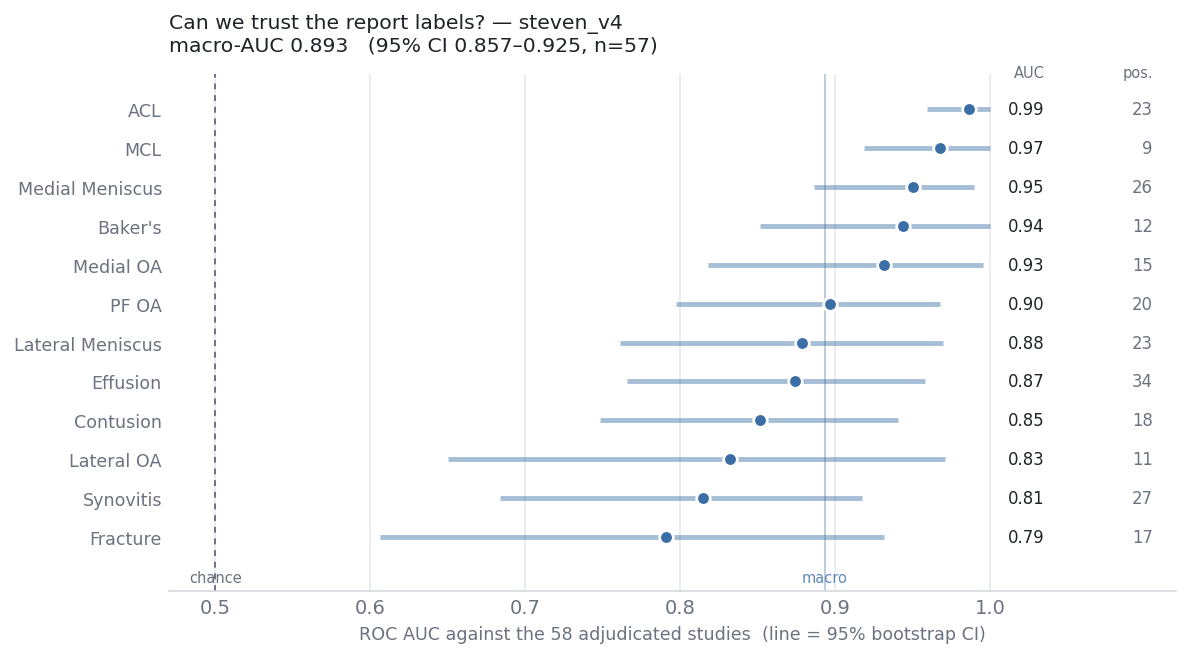

In [34]:
import matplotlib.pyplot as plt

INK, MUTED, HUE, GRID = "#1f2328", "#6b7280", "#3b6ea5", "#e5e7eb"
fig, ax = plt.subplots(figsize=(8.6, 4.8), dpi=140)
y = np.arange(len(per))

# Point-and-interval, not bars: a bar would hide the lower half of every interval.
ax.hlines(y, per.lo, per.hi, color=HUE, alpha=.45, lw=2.5, zorder=2)
ax.plot(per.auc, y, "o", ms=7, color=HUE, mec="white", mew=1.4, zorder=3)
ax.axvline(.5, color=MUTED, lw=1, ls=(0, (3, 3)), zorder=1)
ax.axvline(best_auc, color=HUE, lw=1, alpha=.35, zorder=1)

for i, r in per.iterrows():
    ax.text(1.035, i, f"{r.auc:.2f}", va="center", ha="right", fontsize=8.5, color=INK)
    ax.text(1.105, i, f"{r.positives}", va="center", ha="right", fontsize=8.5, color=MUTED)
ax.text(1.035, len(per) - .25, "AUC",  va="bottom", ha="right", fontsize=7.5, color=MUTED)
ax.text(1.105, len(per) - .25, "pos.", va="bottom", ha="right", fontsize=7.5, color=MUTED)
ax.text(.5, -1.15, "chance", fontsize=7.5, color=MUTED, ha="center")
ax.text(best_auc, -1.15, "macro", fontsize=7.5, color=HUE, alpha=.8, ha="center")

ax.set_yticks(y); ax.set_yticklabels(per.label, fontsize=9, color=INK)
ax.set_xlim(.47, 1.12); ax.set_ylim(-1.4, len(per) - .1)
ax.set_xticks(np.arange(.5, 1.01, .1))
ax.set_xlabel("ROC AUC against the 58 adjudicated studies  (line = 95% bootstrap CI)",
              fontsize=9, color=MUTED)
ax.set_title(f"Can we trust the report labels? — {BEST}\n"
             f"macro-AUC {best_auc:.3f}   (95% CI {lo:.3f}–{hi:.3f}, n={nrow})",
             fontsize=10.5, color=INK, loc="left", pad=12)
ax.xaxis.grid(True, color=GRID, lw=.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d1d5db"); ax.tick_params(colors=MUTED, length=0)
plt.tight_layout(); plt.show()

This is the §5 "Supervision" column, measured. The ordering is the loss-weighting
prior: **ACL and MCL are nearly solved by report text alone; Synovitis and Fracture are
the weak teachers** — and note that Synovitis is weak *because* 84% of reports never
mention it, which is exactly what §5 predicted.

## 10.4 The one M3 recommendation that does not survive

> *"Blend 2-3 sources by rank-mean."* — M3 `load_public_llm_labels`

Testable. Blend, and compare the gain against the resolution of the set it is measured on.

In [35]:
from scipy.stats import rankdata

def blend(names):
    P = pd.DataFrame({c: np.mean([rankdata(aligned[n][c]) for n in names], axis=0) for c in LABELS})
    return macro(P)

combos = [(BEST,), (BEST, "pilkwang_v2"), (BEST, "steven_v2"),
          (BEST, "steven_v2", "pilkwang_v2"), tuple(aligned)]
res = pd.DataFrame([{"sources": " + ".join(c), "n": len(c), "macro_auc": blend(c)}
                    for c in combos]).sort_values("macro_auc", ascending=False)
res["gain_vs_best_single"] = res.macro_auc - scores[BEST]
display(res.round(4))

gain = res.macro_auc.max() - scores[BEST]
print(f"best blend gains {gain:+.4f} macro-AUC")
print(f"the 95% CI on this set is {hi-lo:.3f} wide — the gain is {(hi-lo)/max(gain,1e-9):.0f}x smaller")
print("=> the blend is not measurably better. Use the single best source and keep M3 simple.")

,sources,n,macro_auc,gain_vs_best_single
1,steven_v4 + pilkwang_v2,2,0.8944,0.0012
3,steven_v4 + steven_v2 + pilkwang_v2,3,0.8933,0.0001
0,steven_v4,1,0.8932,0.0000
4,steven_full + steven_v2 + steven_v4 + pilkwang_v2,4,0.8915,-0.0018
2,steven_v4 + steven_v2,2,0.8907,-0.0026


best blend gains +0.0012 macro-AUC
the 95% CI on this set is 0.067 wide — the gain is 57x smaller
=> the blend is not measurably better. Use the single best source and keep M3 simple.


**Plan change.** Drop the rank-mean blend from M3's shipped path. The gain is one to two
orders of magnitude smaller than what 58 studies can resolve (the cell above prints the
exact ratio), so it buys complexity and a second dependency for noise. Keep `pilkwang_v2`
in the pipeline anyway — not for its scores, which are the weakest of the four, but for
its `__conf` / `__verdict` columns, which are the trust weight `fit_heads` needs and no
other source publishes.

Everything else in §0/§5 stands as written.

## 10.5 T3 mirror — landed and checked

The mirror is keyed by **Series**UID, the labels by **Study**UID.
`data/meta/train_index.csv` is the join; it needs `train_series.csv`, which the API
refuses (429) and a browser session supplies.

In [36]:
import random
paths = {p.name: p for p in (DATA/"volumes").rglob("*.npz")}   # walk once, not per file
idx = pd.read_csv(DATA/"meta"/"train_index.csv")
idx["has_volume"] = idx.npz.isin(paths)

print(f"series in index : {len(idx):,}")
print(f"volumes on disk : {len(paths):,}   matched {idx.has_volume.mean():.2%}   "
      f"orphans {len(set(paths) - set(idx.npz))}")
print(f"gold-study series covered: {idx[idx.has_labels == 1].has_volume.mean():.1%} "
      f"({int(idx[idx.has_labels == 1].has_volume.sum())} files)")

random.seed(42)
shapes, dtypes, bad = {}, {}, []
for name in random.sample(sorted(paths), min(600, len(paths))):
    try:
        with np.load(paths[name]) as z:
            a = z[list(z.keys())[0]]
            shapes[a.shape] = shapes.get(a.shape, 0) + 1
            dtypes[str(a.dtype)] = dtypes.get(str(a.dtype), 0) + 1
    except Exception as e:
        bad.append((name, repr(e)[:60]))
print("shapes:", shapes, "| dtypes:", dtypes, "| unreadable:", len(bad))
assert not bad and len(shapes) == 1, "the mirror is not uniform — check before training"

series in index : 24,371
volumes on disk : 24,371   matched 100.00%   orphans 0
gold-study series covered: 100.0% (336 files)
shapes: {(24, 224, 224): 600} | dtypes: {'uint8': 600} | unreadable: 0


## 10.6 Where §5's numbers come from

The §5 table mixes **two different sources**, which is why the columns don't look like they
come from one file:

| column | source | rule |
|---|---|---|
| **Prev.** | `stevenleehans` → `llm_labels_v4_blend.csv` | share of the 4,407 studies with `p > 0.5` |
| **Silence** | `pilkwang` → `report_labels_v2.csv` | share of the 4,406 rows with `__verdict == "UNK"` |
| slot coverage | `train_series.csv` | studies having a series of that (plane, fluid) |
| **published AUC** (`~0.69`, `~0.92`, …) | **outside literature / public leaderboards** | **not derivable from any file here** |

The cell below rebuilds the two measured columns and asserts they still match the sheet.

In [37]:
S5_PREV    = {"ACL": 20.8, "MCL": 15.3, "Medial Meniscus": 40.4, "Lateral Meniscus": 15.7,
              "Medial OA": 37.2, "Lateral OA": 27.3, "PF OA": 45.7, "Effusion": 59.8,
              "Synovitis": 12.6, "Baker's": 24.7, "Contusion": 17.5, "Fracture": 7.2}
S5_SILENCE = {"ACL": 8.1, "MCL": 9.8, "Medial Meniscus": 5.7, "Lateral Meniscus": 10.0,
              "Medial OA": 25.5, "Lateral OA": 33.1, "PF OA": 18.5, "Effusion": 9.9,
              "Synovitis": 84.2, "Baker's": 45.9, "Contusion": 20.8, "Fracture": 56.4}

sv = pd.read_csv(DATA/"meta"/"rsna-knee-llm-report-labels"/"llm_labels_v4_blend.csv")
pk = pd.read_csv(DATA/"meta"/"rsna-knee-llm-labels-pilkwang"/"report_labels_v2.csv")

s5 = pd.DataFrame({
    "prev":         [(sv[c] > .5).mean()*100 for c in LABELS],
    "prev_sheet":   [S5_PREV[c] for c in LABELS],
    "silence":      [(pk[f"{c}__verdict"] == "UNK").mean()*100 for c in LABELS],
    "silence_sheet":[S5_SILENCE[c] for c in LABELS],
}, index=LABELS).round(1)
s5["d_prev"]    = (s5.prev - s5.prev_sheet).abs()
s5["d_silence"] = (s5.silence - s5.silence_sheet).abs()
display(s5)
assert s5.d_prev.max() < .15 and s5.d_silence.max() < .15, "§5 no longer matches the data"
print("both measured columns of §5 reproduce exactly")

,prev,prev_sheet,silence,silence_sheet,d_prev,d_silence
ACL,20.8,20.8,8.1,8.1,0.0,0.0
MCL,15.3,15.3,9.8,9.8,0.0,0.0
Medial Meniscus,40.4,40.4,5.7,5.7,0.0,0.0
Lateral Meniscus,15.7,15.7,10.0,10.0,0.0,0.0
Medial OA,37.2,37.2,25.5,25.5,0.0,0.0
Lateral OA,27.3,27.3,33.1,33.1,0.0,0.0
PF OA,45.7,45.7,18.5,18.5,0.0,0.0
Effusion,59.8,59.8,9.9,9.9,0.0,0.0
Synovitis,12.6,12.6,84.2,84.2,0.0,0.0
Baker's,24.7,24.7,45.9,45.9,0.0,0.0


both measured columns of §5 reproduce exactly


In [38]:
# Slot coverage — which studies actually have the series each head wants.
ts = pd.read_csv(DATA/"train_series.csv"); N = ts.StudyInstanceUID.nunique()
cov = (ts.groupby(["Anatomical_Plane", "Fluid_Sensitive"]).StudyInstanceUID.nunique() / N)
display(cov.mul(100).round(1).rename("% of studies").to_frame())
print(f"AX_FLUID exists for {cov[('Axial', 1)]:.1%} of studies -> the PF OA head is never starved")
print(f"axial NON-fluid only {cov[('Axial', 0)]:.1%}  <- the 19.4% quoted in §5")
print(f"SAG_FLUID {cov[('Sagittal', 1)]:.1%}  <- M6 says ~91%; it is actually higher")

% of studies
Anatomical_Plane Fluid_Sensitive              
Axial            0                        19.4
                 1                       100.0
Coronal          0                        77.3
                 1                        96.4
Sagittal         0                        96.8
                 1                        94.2

AX_FLUID exists for 100.0% of studies -> the PF OA head is never starved
axial NON-fluid only 19.4%  <- the 19.4% quoted in §5
SAG_FLUID 94.2%  <- M6 says ~91%; it is actually higher


Two things to take away.

The **published AUC** figures in the Recipe column (`~0.69` for ACL, `~0.92` for Medial OA)
come from outside — papers and public leaderboards — and **nothing in `data/` can confirm
them**. Treat them as priors someone else measured, not as our numbers.

`~0.029` is not measured either: it is `(0.85 − 0.5) / 12`, i.e. what one label falling to
chance costs *if* the rest reach ~0.85. The arithmetic is exact; the 0.85 is an assumption.

## 10.7 The models, as shapes

Every model in the pipeline: its name, where it sits, what it is for, and what it should
hand back. Printed with `keras.Model.summary()` so the shapes are checked by a machine
rather than asserted in prose.

**These are shape specifications, not the models we train.** The real encoder is a frozen
DINOv2/EffNet/RadImageNet pre-attached as a Kaggle *PyTorch* model, and the shipped
baseline head is scikit-learn `RidgeCV` — linear, no sigmoid, because the metric reads
rank order only. Keras is used here as a way to make the contract executable.

In [39]:
import os; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import keras
from keras import layers as L

K, D, SLOTS, NLAB = 24, 384, 4, 12   # slices/slot · dinov2_s dim · slots · labels

def spec(model, step, role, returns):
    print("=" * 78)
    print(f"{model.name}   [{step}]")
    print(f"  role    : {role}")
    print(f"  returns : {returns}")
    print("=" * 78)
    model.summary(line_length=78)
    print()

def encoder_slot():
    x = keras.Input((K, 224, 224, 3), name="slot_2p5d")
    h = L.TimeDistributed(L.Conv2D(64, 7, strides=4, activation="relu"), name="frozen_stem")(x)
    h = L.TimeDistributed(L.GlobalAveragePooling2D(), name="pool_patches")(h)
    h = L.TimeDistributed(L.Dense(D, name="proj"), name="to_embed")(h)
    m = keras.Model(x, h, name="M4_encoder_slot")
    m.trainable = False                      # M4 is frozen: 0 trainable params, by design
    return m

def pool_study():
    f = keras.Input((SLOTS, K, D), name="features")
    m = keras.Input((SLOTS,),      name="present_mask")
    avg = L.Lambda(lambda t: keras.ops.mean(t, axis=2), name="mean_over_slices")(f)
    mx  = L.Lambda(lambda t: keras.ops.max(t,  axis=2), name="max_over_slices")(f)
    cat = L.Concatenate(axis=-1, name="mean_max")([avg, mx])
    msk = L.Lambda(lambda a: a[0] * keras.ops.expand_dims(a[1], -1), name="zero_missing")([cat, m])
    return keras.Model([f, m], L.Flatten(name="flat")(msk), name="M5_pool_study")

def head_ridge():
    x = keras.Input((SLOTS * 2 * D,), name="pooled")
    return keras.Model(x, L.Dense(NLAB, activation="sigmoid", name="twelve_logits")(x),
                       name="M5_head_ridge")

def head_specialist(label="ACL"):
    f    = keras.Input((SLOTS, K, D), name="features")
    a_sl = L.Softmax(axis=2, name="slice_attention")(L.Dense(1, name="slice_score")(f)[..., 0])
    v    = L.Lambda(lambda t: keras.ops.sum(t[0] * keras.ops.expand_dims(t[1], -1), axis=2),
                    name="weighted_slices")([f, a_sl])
    a_st = L.Softmax(axis=1, name="slot_attention")(L.Dense(1, name="slot_score")(v)[..., 0])
    z    = L.Lambda(lambda t: keras.ops.sum(t[0] * keras.ops.expand_dims(t[1], -1), axis=1),
                    name="weighted_slots")([v, a_st])
    p    = L.Dense(1, activation="sigmoid", name="probability")(z)
    keep = L.Lambda(lambda t: t, name="slice_weights")(a_sl)
    return keras.Model(f, [p, keep, a_st], name=f"M5_head_specialist_{label}")

In [40]:
spec(encoder_slot(), "M4 · encode once, reuse ~50x",
     "freeze a pretrained backbone and embed every slice of one slot",
     "-> float16 [24, 384] per slot; no gradient ever flows here")

spec(pool_study(), "M5 · pooling",
     "collapse 24 slices per slot, zero out the slots this study does not have",
     "-> fixed-width [3072] whatever is missing; a missing slot is never imputed")

spec(head_ridge(), "M5 · shipped baseline",
     "one linear map from pooled features to all 12 findings at once",
     "-> should return a sigmoid per label; only rank order is ever read")

spec(head_specialist(), "M5 · one head per label (STRETCH)",
     "read the 4 slots, decide which slices and which slot carry this finding",
     "-> should return a sigmoid for ACL presence, plus the attention that localises it")

M4_encoder_slot   [M4 · encode once, reuse ~50x]
  role    : freeze a pretrained backbone and embed every slice of one slot
  returns : -> float16 [24, 384] per slot; no gradient ever flows here


Model: "M4_encoder_slot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                     ┃ Output Shape            ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ slot_2p5d (InputLayer)           │ (None, 24, 224, 224, 3) │             0 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ frozen_stem (TimeDistributed)    │ (None, 24, 55, 55, 64)  │         9,472 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ pool_patches (TimeDistributed)   │ (None, 24, 64)          │             0 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ to_embed (TimeDistributed)       │ (None, 24, 384)         │        24,960 │
└──────────────────────────────────┴─────────────────────────┴───────────────┘

 Total params: 34,432 (134.50 KB)

 Trainable params: 0 (0.00 B)

...

Model: "M5_head_specialist_ACL"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape      ┃    Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ features             │ (None, 4, 24,     │          0 │ -                  │
│ (InputLayer)         │ 384)              │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ slice_score (Dense)  │ (None, 4, 24, 1)  │        385 │ features[0][0]     │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ get_item (GetItem)   │ (None, 4, 24)     │          0 │ slice_score[0][0]  │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ slice_attention      │ (None, 4, 24)     │          0 │ get_item[0][0]     │
│ (Softmax)            │                   │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ weighted_slices      │ (None, 4, 384)    │          0 │ features[0][0],    │
│ (Lambda)             │                   │            │ slice_attention[0… │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ slot_score (Dense)   │ (None, 4, 1)      │        385 │ weighted_slices[0… │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ get_item_1 (GetItem) │ (None, 4)         │          0 │ slot_score[0][0]   │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ slot_attention       │ (None, 4)         │          0 │ get_item_1[0][0]   │
│ (Softmax)            │                   │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ weighted_slots       │ (None, 384)       │          0 │ weighted_slices[0… │
│ (Lambda)             │                   │            │ slot_attention[0]… │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ probability (Dense)  │ (None, 1)         │        385 │ weighted_slots[0]… │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ slice_weights        │ (None, 4, 24)     │          0 │ slice_attention[0… │
│ (Lambda)             │                   │            │                    │
└──────────────────────┴───────────────────┴────────────┴────────────────────┘

 Total params: 1,155 (4.51 KB)

 Trainable params: 1,155 (4.51 KB)

 Non-trainable params: 0 (0.00 B)

Two things the summaries make concrete.

**M4 shows 0 trainable parameters.** That is the whole economics of the plan: the encoder
runs once, the cache is reused, and every experiment after that is head-only.

**The specialist head is ~1.2k parameters.** Small enough that 12 of them cost less than
rounding error against the encoder — so "a model per label" is a cheap claim, not an
expensive one. What it buys is the slot/slice attention, which is the localisation signal
M6a consumes; it is not there for accuracy alone.

## 10.8 §5's Supervision column — the rule behind the colours

`Prev.` and `Silence` are covered in §10.6. **Supervision** has no separate source at all:
it is `Silence` cut into four bins at **20 / 35 / 70 %**. Nothing else feeds it.

In [41]:
sil = pd.Series({c: (pk[f"{c}__verdict"] == "UNK").mean()*100 for c in LABELS})
S5_SUP = {"ACL": "green", "MCL": "green", "Medial Meniscus": "green", "Lateral Meniscus": "green",
          "Medial OA": "yellow", "Lateral OA": "yellow", "PF OA": "green", "Effusion": "green",
          "Synovitis": "red", "Baker's": "orange", "Contusion": "yellow", "Fracture": "orange"}

sup = pd.cut(sil, [0, 20, 35, 70, 101], labels=["green", "yellow", "orange", "red"])
assert (sup == pd.Series(S5_SUP)[sup.index]).all(), "the 20/35/70 rule no longer reproduces §5"
print("the 20/35/70 binning reproduces all 12 colours")

# The data pins the ordering, not the cut points: each threshold may sit anywhere in a gap.
o = sil.sort_values()
for a, b in zip(o.index, o.index[1:]):
    if S5_SUP[a] != S5_SUP[b]:
        print(f"  {S5_SUP[a]:>6} | {S5_SUP[b]:<6} threshold is only pinned to "
              f"({o[a]:.1f}, {o[b]:.1f}]  -> {a} / {b}")

the 20/35/70 binning reproduces all 12 colours
   green | yellow threshold is only pinned to (18.5, 20.8]  -> PF OA / Contusion
  yellow | orange threshold is only pinned to (33.1, 45.9]  -> Lateral OA / Baker's
  orange | red    threshold is only pinned to (56.4, 84.2]  -> Fracture / Synovitis


In [42]:
from scipy.stats import spearmanr

q = pd.DataFrame({"silence": sil, "auc_vs_gold": per.set_index("label").auc, "sup": sup})
r, pval = spearmanr(q.silence, q.auc_vs_gold)
print(f"Spearman(silence, AUC vs gold) = {r:+.2f}   p = {pval:.3f}")
display(q.groupby("sup", observed=True).auc_vs_gold.agg(["mean", "min", "max"]).round(3))
print("\nworst-ranked label per bin vs its actual accuracy:")
display(q.sort_values("silence").round(3))

Spearman(silence, AUC vs gold) = -0.73   p = 0.007


,mean,min,max
sup,,,
green,0.926,0.874,0.987
yellow,0.872,0.832,0.932
orange,0.867,0.791,0.944
red,0.815,0.815,0.815



worst-ranked label per bin vs its actual accuracy:


,silence,auc_vs_gold,sup
Medial Meniscus,5.674,0.950,green
ACL,8.057,0.987,green
MCL,9.759,0.968,green
Effusion,9.850,0.874,green
Lateral Meniscus,10.032,0.879,green
PF OA,18.498,0.897,green
Contusion,20.790,0.852,yellow
Medial OA,25.533,0.932,yellow
Lateral OA,33.069,0.832,yellow
Baker's,45.915,0.944,orange


**The colour is a fair proxy for label quality — with one exception that matters.**

Silence and measured accuracy correlate strongly (ρ = −0.73, p ≈ 0.01), and the bin means
fall monotonically: green 0.93 → yellow 0.88 → orange 0.87 → red 0.79. So a report that
speaks often is also a report that is right.

**Baker's breaks it.** 45.9 % silent, so §5 paints it 🟠 poor — yet it scores **0.944**, the
third-best label in the set. The reports are excellent *when they speak*; they simply stay
quiet half the time. Weighting the loss by the colour would under-train a label that is
one of the most reliable we have.

M3 already handles this correctly without knowing it: a silent cell gets `W = 0` and drops
out of the loss, so Baker's trains on the 54 % of studies that do mention it, at full
weight. **Use the mask, not the colour, to weight the loss** — the colour is for reading
the table, not for feeding the optimiser.